# Gaussian Naive Bayes adaptado a `penguins.csv`

## Objetivo
Adaptar el notebook original basado en **Iris** para que funcione con tu archivo **penguins.csv**, corrigiendo los problemas típicos que aparecen al cambiar de dataset:

- cargar un CSV en lugar de `load_iris()`,
- eliminar la columna índice `Unnamed: 0`,
- tratar valores faltantes,
- definir la variable objetivo (`species`),
- codificar las clases de texto a números,
- entrenar y evaluar el modelo con tus datos.


## Bloque 1. Importar librerías

Aquí se cargan las librerías necesarias para:
- leer el CSV,
- limpiar los datos,
- visualizar el problema,
- entrenar Gaussian Naive Bayes,
- y evaluar el modelo.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

Matplotlib is building the font cache; this may take a moment.


### Qué cambia frente al notebook original

En el notebook original se usaba:

```python
from sklearn.datasets import load_iris
iris = load_iris()
```

Eso ya no sirve para tu caso, porque ahora trabajamos con un archivo externo (`penguins.csv`) y no con el dataset incorporado de scikit-learn.


## Bloque 2. Cargar el CSV y explorar la estructura

Primero localizamos el archivo, lo leemos y revisamos su forma general.


In [ ]:
possible_paths = [
    Path("penguins.csv"),
    Path("/mnt/data/penguins.csv")
]

csv_path = None
for p in possible_paths:
    if p.exists():
        csv_path = p
        break

if csv_path is None:
    raise FileNotFoundError("No se encontró el archivo penguins.csv")

df = pd.read_csv(csv_path)

print("Archivo cargado desde:", csv_path)
print("Shape del dataset:", df.shape)
print("\nColumnas:")
print(df.columns.tolist())

print("\nPrimeras 5 filas:")
display(df.head())

Archivo cargado desde: penguins.csv
Shape del dataset: (344, 9)

Columnas:
['Unnamed: 0', 'species', 'island', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'sex', 'year']

Primeras 5 filas:


,Unnamed: 0,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,1,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,2,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,3,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,4,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,5,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


### Interpretación del bloque 2

Aquí aparece el primer detalle importante: el CSV trae una columna llamada **`Unnamed: 0`**, que normalmente es un índice guardado por error al exportar.  
Esa columna no aporta valor predictivo y debe eliminarse.


## Bloque 3. Limpiar la data y seleccionar variables

Vamos a:
1. eliminar `Unnamed: 0`,
2. quedarnos con variables numéricas útiles,
3. eliminar filas con nulos en las columnas necesarias,
4. separar variables predictoras y variable objetivo.


In [ ]:
# Eliminamos la columna índice si existe
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

# Seleccionamos columnas numéricas y la clase objetivo
feature_cols = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
target_col = "species"

# Nos quedamos solo con las columnas necesarias
data = df[feature_cols + [target_col]].copy()

print("Valores faltantes antes de limpiar:")
print(data.isna().sum())

# Eliminamos filas con nulos en las variables requeridas
data = data.dropna().reset_index(drop=True)

print("\nShape luego de limpiar:", data.shape)
print("\nValores faltantes después de limpiar:")
print(data.isna().sum())

display(data.head())

Valores faltantes antes de limpiar:
bill_length_mm       2
bill_depth_mm        2
flipper_length_mm    2
body_mass_g          2
species              0
dtype: int64

Shape luego de limpiar: (342, 5)

Valores faltantes después de limpiar:
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
species              0
dtype: int64


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,species
0,39.1,18.7,181.0,3750.0,Adelie
1,39.5,17.4,186.0,3800.0,Adelie
2,40.3,18.0,195.0,3250.0,Adelie
3,36.7,19.3,193.0,3450.0,Adelie
4,39.3,20.6,190.0,3650.0,Adelie


### Error corregido aquí

Si intentaras entrenar el modelo con nulos, aparecería un error similar a este:

```python
ValueError: Input X contains NaN
```

La corrección aplicada fue eliminar las filas con faltantes en las variables necesarias.  
Para este ejercicio es una solución simple y válida.


## Bloque 4. Codificar la variable objetivo

`species` está en texto (`Adelie`, `Chinstrap`, `Gentoo`), pero el modelo trabaja mejor si las clases están codificadas numéricamente.


In [ ]:
label_encoder = LabelEncoder()
data["species_label"] = label_encoder.fit_transform(data[target_col])

X = data[feature_cols].values
y = data["species_label"].values
class_names = label_encoder.classes_

print("Shape de X:", X.shape)
print("Shape de y:", y.shape)
print("Clases codificadas:", list(class_names))

print("\nPrimeras 5 observaciones de X:")
print(X[:5])

print("\nPrimeras 5 etiquetas de y:")
print(y[:5])

Shape de X: (342, 4)
Shape de y: (342,)
Clases codificadas: ['Adelie', 'Chinstrap', 'Gentoo']

Primeras 5 observaciones de X:
[[  39.1   18.7  181.  3750. ]
 [  39.5   17.4  186.  3800. ]
 [  40.3   18.   195.  3250. ]
 [  36.7   19.3  193.  3450. ]
 [  39.3   20.6  190.  3650. ]]

Primeras 5 etiquetas de y:
[0 0 0 0 0]


### Interpretación del bloque 4

Ya convertimos el problema en una clasificación supervisada con:
- **X**: medidas del pingüino,
- **y**: especie codificada numéricamente.


## Bloque 5. Visualizar dos variables en 2D

Usaremos las dos primeras variables:
- `bill_length_mm`
- `bill_depth_mm`

Esto no afecta el entrenamiento principal; solo sirve para entender la separación entre clases.


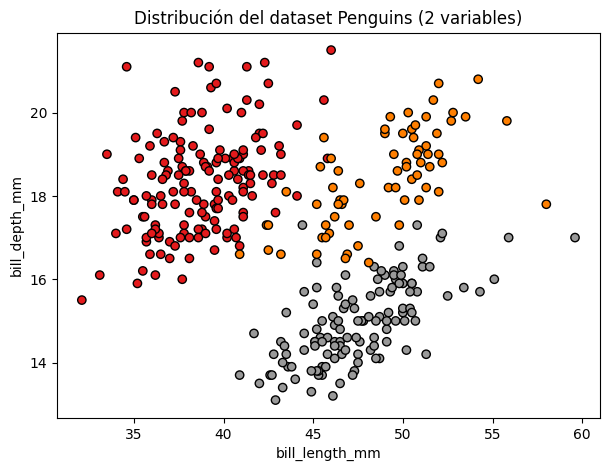

In [ ]:
X_vis = data[["bill_length_mm", "bill_depth_mm"]].values

_, ax = plt.subplots(figsize=(7, 5))
ax.scatter(
    X_vis[:, 0],
    X_vis[:, 1],
    c=y,
    cmap="Set1",
    edgecolors="k"
)

ax.set_title("Distribución del dataset Penguins (2 variables)")
ax.set_xlabel("bill_length_mm")
ax.set_ylabel("bill_depth_mm")
plt.show()

## Bloque 6. Dividir datos en entrenamiento y prueba

Separamos el dataset en:
- 70% para entrenamiento
- 30% para prueba

Usamos `stratify=y` para conservar la proporción de especies.


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("Shape de X_train:", X_train.shape)
print("Shape de X_test:", X_test.shape)
print("Shape de y_train:", y_train.shape)
print("Shape de y_test:", y_test.shape)

Shape de X_train: (239, 4)
Shape de X_test: (103, 4)
Shape de y_train: (239,)
Shape de y_test: (103,)


## Bloque 7. Crear y entrenar Gaussian Naive Bayes

Aquí entrenamos el clasificador usando tus datos reales.


In [ ]:
gnb = GaussianNB()
gnb.fit(X_train, y_train)

print("Modelo GaussianNB entrenado correctamente con penguins.csv")

Modelo GaussianNB entrenado correctamente con penguins.csv


## Bloque 8. Hacer predicciones y evaluar el modelo

Calculamos:
- accuracy,
- matriz de confusión,
- reporte de clasificación.


In [ ]:
y_pred = gnb.predict(X_test)

acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred, target_names=class_names)

print("Accuracy:", acc)
print("\nMatriz de confusión:")
print(cm)
print("\nReporte de clasificación:")
print(report)

Accuracy: 0.970873786407767

Matriz de confusión:
[[44  1  0]
 [ 2 19  0]
 [ 0  0 37]]

Reporte de clasificación:
              precision    recall  f1-score   support

      Adelie       0.96      0.98      0.97        45
   Chinstrap       0.95      0.90      0.93        21
      Gentoo       1.00      1.00      1.00        37

    accuracy                           0.97       103
   macro avg       0.97      0.96      0.96       103
weighted avg       0.97      0.97      0.97       103



### Interpretación del bloque 8

Si el accuracy es alto y la diagonal de la matriz de confusión domina, el modelo está separando bien las especies de pingüinos con las 4 variables numéricas.


## Bloque 9. Visualizar fronteras de decisión en 2D

Entrenamos un GaussianNB usando solo las dos variables visuales para dibujar cómo separa el plano.


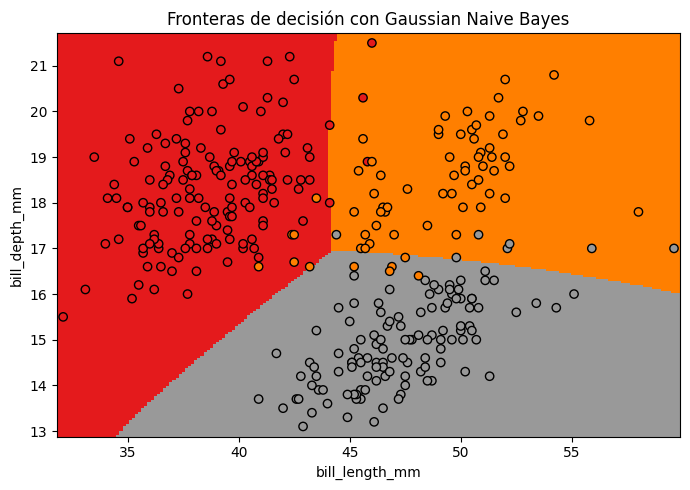

In [ ]:
gnb_vis = GaussianNB()
gnb_vis.fit(X_vis, y)

offset = 0.2
x_min, x_max = X_vis[:, 0].min() - offset, X_vis[:, 0].max() + offset
y_min, y_max = X_vis[:, 1].min() - offset, X_vis[:, 1].max() + offset

x_grid, y_grid = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

pred_grid = gnb_vis.predict(np.c_[x_grid.ravel(), y_grid.ravel()])
pred_grid = pred_grid.reshape(x_grid.shape)

_, ax = plt.subplots(figsize=(7, 5))
ax.pcolormesh(x_grid, y_grid, pred_grid, cmap="Set1", shading="auto")
ax.scatter(X_vis[:, 0], X_vis[:, 1], c=y, cmap="Set1", edgecolors="k")

ax.set_title("Fronteras de decisión con Gaussian Naive Bayes")
ax.set_xlabel("bill_length_mm")
ax.set_ylabel("bill_depth_mm")

plt.tight_layout()
plt.show()

## Bloque 10. Probar el modelo con un nuevo pingüino

Ahora hacemos una predicción con un ejemplo nuevo:
- pico largo: 46 mm
- profundidad del pico: 14.5 mm
- aleta: 215 mm
- masa corporal: 5000 g


In [ ]:
nuevo_pinguino = np.array([[46.0, 14.5, 215.0, 5000.0]])

pred_nuevo = gnb.predict(nuevo_pinguino)[0]
prob_nuevo = gnb.predict_proba(nuevo_pinguino)[0]

print("Nuevo pingüino:", nuevo_pinguino)
print("Clase predicha:", pred_nuevo)
print("Especie predicha:", class_names[pred_nuevo])

print("\nProbabilidades por clase:")
for i, prob in enumerate(prob_nuevo):
    print(f"  {class_names[i]}: {prob:.6f}")

Nuevo pingüino: [[  46.    14.5  215.  5000. ]]
Clase predicha: 2
Especie predicha: Gentoo

Probabilidades por clase:
  Adelie: 0.000000
  Chinstrap: 0.000000
  Gentoo: 1.000000


## Conclusión

Este notebook ya quedó adaptado a tu CSV.  
Los cambios clave fueron:

1. reemplazar `load_iris()` por `pd.read_csv()`,
2. eliminar `Unnamed: 0`,
3. limpiar nulos,
4. codificar `species`,
5. entrenar GaussianNB con las variables de `penguins.csv`.

Puedes usar la misma lógica con otros CSV similares siempre que definas:
- columnas predictoras,
- columna objetivo,
- y estrategia de limpieza.
